# ELISA Antibody Pair Screening — Signal-to-Noise Ratio

**Figure context:** This notebook produces the paired bar chart showing signal-to-noise ratio (SNR) at 2000 pg/mL for each antibody capture–detector pair tested in sandwich ELISA format.  
Two NfL protein sources are compared side-by-side for each pair:
- **bNfL (Uman)** — bovine NfL from IBL/Uman Diagnostics  
- **rhNfL (PK)** — recombinant human NfL from PerkinElmer  

Pairs with SNR < 5 for both proteins are excluded from the figure to focus attention on candidates with meaningful signal above background.

**Source data:** `SNR_all.csv` (same directory)  
**Output:** `fig_snr_ab_pairs.svg` (300 DPI, double-column width)

## 1. Environment setup

Imports ProxiPal (the project's custom statistics and utilities module) and standard scientific Python libraries.  
ProxiPal also sets up folder paths for the full installation — these printouts can be ignored when running from the standalone GitHub repository.

In [1]:
import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# Folder path printouts below are only relevant for full ProxiPal installations.
# See: https://github.com/proxipal-pcr

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-05-19 13:22:39
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\ELISA Ab SNR
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\OneDri

## 2. Global figure style

Sets matplotlib rcParams once for the entire notebook, consistent with the project-wide style specification.  
- Font: Helvetica/Arial, 6 pt throughout (matches Nature Communications single-column figure standards)
- Colour palette: Okabe-Ito — a perceptually uniform, colorblind-safe categorical palette

These parameters are **not** repeated inside individual plot functions.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# --- Global rcParams (set once) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
plt.rcParams['font.size'] = 6
plt.rcParams['axes.titlesize'] = 6
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['axes.linewidth'] = 0.6

# --- Okabe-Ito colour palette ---
# Perceptually uniform and safe for the most common forms of color vision deficiency.
# Reference: Okabe & Ito (2002), https://jfly.uni-koeln.de/color/
okabe_ito = {
    'orange':         '#E69F00',
    'sky blue':       '#56B4E9',
    'bluish green':   '#009E73',
    'yellow':         '#F0E442',
    'blue':           '#0072B2',
    'vermillion':     '#D55E00',
    'reddish purple': '#CC79A7',
    'black':          '#000000',
}

# Project-wide calibrator colour map — applied consistently across all figures
calibrator_colours = {
    'Uman':        okabe_ito['black'],
    'Progen':      okabe_ito['vermillion'],
    'R&D':         okabe_ito['reddish purple'],
    'PerkinElmer': okabe_ito['bluish green'],
    'Origene':     okabe_ito['orange'],
    'Abcam':       okabe_ito['blue'],
    'MyBio':       okabe_ito['sky blue'],
    'Ella':        okabe_ito['yellow'],
    'Encor':       okabe_ito['orange'],    # shares colour with Origene
    'Abnova':      okabe_ito['sky blue'],  # shares colour with MyBio
}

# Colours for the two NfL protein sources in this figure — drawn from calibrator_colours
COLOR_UMAN = calibrator_colours['Uman']         # bNfL (Uman) — black
COLOR_PE   = calibrator_colours['PerkinElmer']  # rhNfL (PerkinElmer) — bluish green

## 3. Load source data

`SNR_all.csv` contains one row per antibody pair tested. Columns:

| Column | Description |
|--------|-------------|
| `C` | Capture antibody group index |
| `B` | Detector antibody index within group |
| `Capture` | Capture antibody clone identifier |
| `Detector` | Detector antibody clone identifier |
| `IBL_SNR` | SNR at 2000 pg/mL using IBL/Uman bNfL |
| `RnD_SNR` | SNR at 2000 pg/mL using R&D partial-length NfL |
| `PK_SNR` | SNR at 2000 pg/mL using PerkinElmer rhNfL |
| `Label` | Display label: `Capture - Detector` |

Row 0 is the 47:3–2.1 interpolated comparison pair, which is excluded from the figure (see Cell 5).

In [3]:
clone_data = pd.read_csv('SNR_all.csv')
print(f"{len(clone_data)} rows loaded")
clone_data

23 rows loaded


,C,B,Capture,Detector,IBL_SNR,RnD_SNR,PK_SNR,Label
0,47:03:00,2.1,47:03:00,2.1,12.5,10.26,NaN,47:3 - 2.1
1,1,3.0,268014,NfL21,17.4,1.10,3.1,268014 - NfL21
2,1,4.0,268014,NfL23,23.8,1.00,3.8,268014 - NfL23
3,2,1.0,985917,268014,5.7,15.60,12.4,985917 - 268014
4,3,1.0,NfL21,268014,10.6,7.80,4.9,NfL21 - 268014
5,4,1.0,NfL23,268014,9.0,6.20,4.8,NfL23 - 268014
6,6,3.0,OTI3G2,NfL21,6.7,1.00,1.5,OTI3G2 - NfL21
7,6,4.0,OTI3G2,NfL23,8.5,0.90,1.9,OTI3G2 - NfL23
8,6,7.0,OTI3G2,OTI2F5,7.4,11.20,1.7,OTI3G2 - OTI2F5
9,7,1.0,OTI2F5,268014,6.3,11.50,3.2,OTI2F5 - 268014


## 4. Filter to figure-eligible pairs

Row 0 (the 47:3–2.1 pair) is an interpolated comparison included in the raw screening data but excluded from the figure, as it does not represent a directly tested combination in the same experimental format as all other pairs.

An additional filter retains only pairs where **either** bNfL (Uman) SNR **or** rhNfL (PK) SNR exceeds 5 — consistent with the figure legend criterion.

In [4]:
# Exclude interpolated pair (row 0) and retain pairs passing the SNR > 5 threshold
df_fig = clone_data.iloc[1:].copy()
df_fig = df_fig[(df_fig['IBL_SNR'] > 5) | (df_fig['PK_SNR'] > 5)].reset_index(drop=True)

print(f"{len(df_fig)} pairs retained for figure")
df_fig[['Label', 'IBL_SNR', 'PK_SNR']]

21 pairs retained for figure


,Label,IBL_SNR,PK_SNR
0,268014 - NfL21,17.4,3.1
1,268014 - NfL23,23.8,3.8
2,985917 - 268014,5.7,12.4
3,NfL21 - 268014,10.6,4.9
4,NfL23 - 268014,9.0,4.8
5,OTI3G2 - NfL21,6.7,1.5
6,OTI3G2 - NfL23,8.5,1.9
7,OTI3G2 - OTI2F5,7.4,1.7
8,OTI2F5 - 268014,6.3,3.2
9,5C12G4 - 268014,16.1,12.3


## 5. Plot: SNR paired bar chart

Paired bars show SNR at 2000 pg/mL for each antibody pair, with the two NfL protein sources (bNfL (Uman) in black, rhNfL PK in vermillion) plotted side by side.

Design notes:
- Bar width set so adjacent pairs remain visually separable at double-column (180 mm) figure width
- x-tick labels rotated 45° — standard for antibody pair identifiers of this length
- Dashed y-grid at 30% alpha — project convention
- SNR = 5 reference line marks the inclusion threshold
- Legend: `frameon=False` — project convention
- Output: SVG at 300 DPI, double-column width (180 mm)

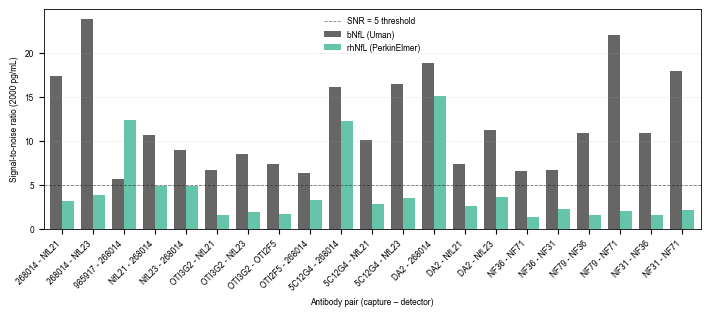

Saved: fig_snr_ab_pairs.svg


In [5]:
def plot_snr_pairs(ax, df):
    """
    Paired bar chart of sandwich ELISA signal-to-noise ratios.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axes object.
    df : pd.DataFrame
        Filtered clone_data. Must contain columns: Label, IBL_SNR, PK_SNR.
    """
    labels  = df['Label'].tolist()
    snr_uman = df['IBL_SNR'].tolist()
    snr_pe   = df['PK_SNR'].tolist()

    x = np.arange(len(labels))
    width = 0.38

    ax.bar(x - width / 2, snr_uman, width,
           color=COLOR_UMAN, alpha=0.6, label='bNfL (Uman)')
    ax.bar(x + width / 2, snr_pe,   width,
           color=COLOR_PE, alpha=0.6, label='rhNfL (PerkinElmer)')

    # SNR = 5 reference threshold
    ax.axhline(5, color='black', linewidth=0.6, linestyle='--', alpha=0.5,
               label='SNR = 5 threshold')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel('Antibody pair (capture – detector)')
    ax.set_ylabel('Signal-to-noise ratio (2000 pg/mL)')
    ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.legend(frameon=False)
    ax.set_xlim(-0.6, len(labels) - 0.4)


# --- Assemble figure ---
fig_width_mm  = 180   # double-column
fig_height_mm = 80

fig, ax = plt.subplots(figsize=(fig_width_mm / 25.4, fig_height_mm / 25.4))
plot_snr_pairs(ax, df_fig)

plt.tight_layout()
plt.savefig('fig_snr_ab_pairs.svg', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_snr_ab_pairs.svg")

## 6. Export source data file

Nature Communications requires source data to be deposited alongside the manuscript.  
The file below contains only the columns that are directly plotted in the figure — consistent with the project convention that each plot function's input CSV *is* the source data file.

Naming convention: `fig_snr_ab_pairs_source_data.csv`

In [6]:
source_data = df_fig[['Label', 'IBL_SNR', 'PK_SNR']].copy()
source_data.columns = ['antibody_pair', 'SNR_bNfL_Uman', 'SNR_rHuNfL_PerkinElmer']
source_data.to_csv('fig_snr_ab_pairs_source_data.csv', index=False)
print("Source data exported:")
source_data

Source data exported:


,antibody_pair,SNR_bNfL_Uman,SNR_rHuNfL_PerkinElmer
0,268014 - NfL21,17.4,3.1
1,268014 - NfL23,23.8,3.8
2,985917 - 268014,5.7,12.4
3,NfL21 - 268014,10.6,4.9
4,NfL23 - 268014,9.0,4.8
5,OTI3G2 - NfL21,6.7,1.5
6,OTI3G2 - NfL23,8.5,1.9
7,OTI3G2 - OTI2F5,7.4,1.7
8,OTI2F5 - 268014,6.3,3.2
9,5C12G4 - 268014,16.1,12.3
